# Задание

Используя шаблон ноутбука для распознавания видов одежды и аксессуаров из набора **fashion_mnist**, выполните следующие действия:

1. Создайте **9** моделей нейронной сети с различными архитектурами и сравните в них значения точности на проверочной выборке (на последней эпохе) и на тестовой выборке.  Используйте следующее деление: обучающая выборка - **50000** примеров, проверочная выборка - **10000** примеров, тестовая выборка - **10000** примеров.

2. Создайте сравнительную таблицу в конце ноутбука, напишите свои выводы по результатам проведенных тестов.

## Импорт библиотек и подготовка данных

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Flatten, Conv2D, MaxPooling2D, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical

from tensorflow.keras.datasets import fashion_mnist

# Загрузка данных
(x_train_full, y_train_full), (x_test, y_test) = fashion_mnist.load_data()

# Разделение
x_train, x_val = x_train_full[:50000], x_train_full[50000:]
y_train, y_val = y_train_full[:50000], y_train_full[50000:]

# Нормализация
x_train = x_train.astype('float32') / 255.0
x_val = x_val.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# One-hot
y_train_cat = to_categorical(y_train, 10)
y_val_cat = to_categorical(y_val, 10)
y_test_cat = to_categorical(y_test, 10)

print("Train:", x_train.shape)
print("Validation:", x_val.shape)
print("Test:", x_test.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train: (50000, 28, 28)
Validation: (10000, 28, 28)
Test: (10000, 28, 28)


## Описание базы

### База: одежда, обувь и аксессуары
- Датасет состоит из набора изображений одежды, обуви, аксессуаров и их классов.
- Изображения одного вида хранятся в numpy-массиве **(28, 28)** - **x_train, x_test**.
- База содержит **10** классов: (Футболка, Брюки, Пуловер, Платье, Пальто, Сандалии/Босоножки, Рубашка, Кроссовки, Сумочка, Ботильоны) - **y_train, y_test**.
- Примеров: train - **60000**, test - **10000**.

## Визуализация

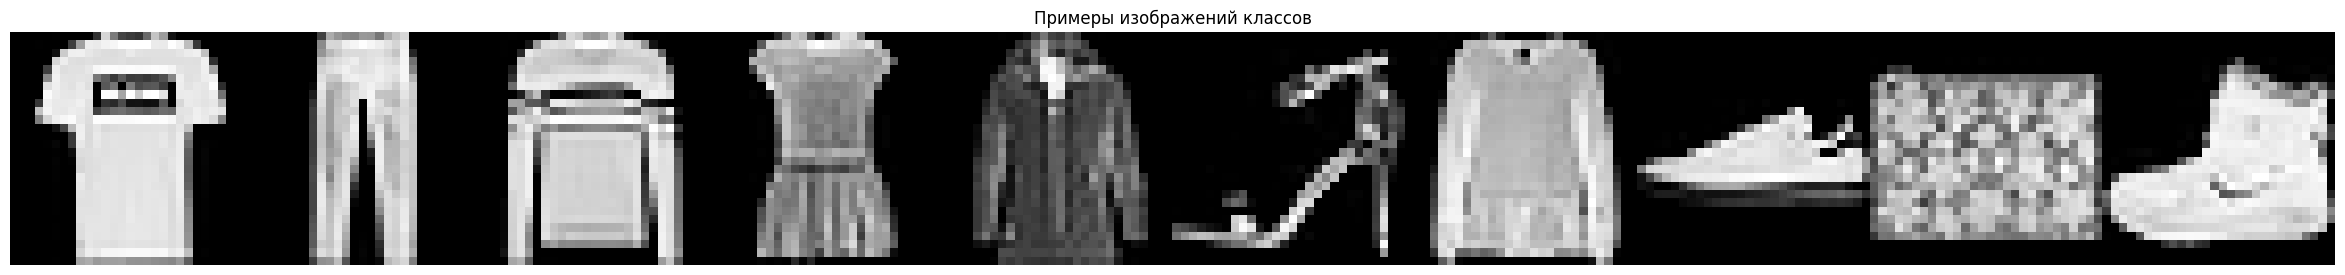

In [5]:
imgs = np.array([x_train[y_train==i][0] for i in range(10)])
imgs = np.concatenate(imgs, axis=1)

plt.figure(figsize=(30,6))
plt.imshow(imgs, cmap='Greys_r')
plt.title("Примеры изображений классов")
plt.axis('off')
plt.show()

## Модель 1 - Базовая полносвязная нейронная сеть (Dense)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8089 - loss: 0.5661 - val_accuracy: 0.8383 - val_loss: 0.4558
Epoch 2/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8565 - loss: 0.4120 - val_accuracy: 0.8518 - val_loss: 0.4177
Epoch 3/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8658 - loss: 0.3789 - val_accuracy: 0.8668 - val_loss: 0.3748
Epoch 4/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8735 - loss: 0.3500 - val_accuracy: 0.8676 - val_loss: 0.3714
Epoch 5/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8843 - loss: 0.3259 - val_accuracy: 0.8771 - val_loss: 0.3518
Epoch 6/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8875 - loss: 0.3132 - val_accuracy: 0.8801 - val_loss: 0.3389
Epoch 7/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8920 - loss: 0.2985 - val_accuracy: 0.8819 - val_loss: 0.3367
Epoch 8/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8973 - loss: 0.2845 - val_accuracy: 0.

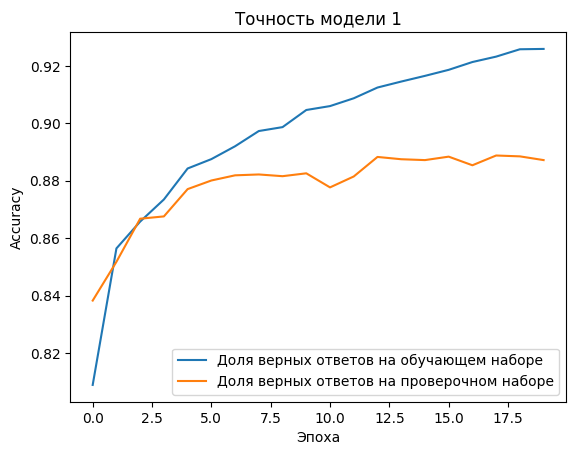

In [6]:
model1 = Sequential([
    Flatten(input_shape=(28,28)),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

model1.compile(loss='categorical_crossentropy', optimizer=Adam(0.001), metrics=['accuracy'])

history1 = model1.fit(x_train, y_train_cat, epochs=20, batch_size=128,
                      validation_data=(x_val, y_val_cat))

scores1 = model1.evaluate(x_test, y_test_cat, verbose=0)

print("Val:", history1.history['val_accuracy'][-1])
print("Test:", scores1[1])

plt.plot(history1.history['accuracy'], label='Доля верных ответов на обучающем наборе')
plt.plot(history1.history['val_accuracy'], label='Доля верных ответов на проверочном наборе')
plt.title("Точность модели 1")
plt.xlabel("Эпоха")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

## Модель 2 - Полносвязная сеть с регуляризацией Dropout

Epoch 1/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.7664 - loss: 0.6590 - val_accuracy: 0.8379 - val_loss: 0.4595
Epoch 2/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8387 - loss: 0.4460 - val_accuracy: 0.8561 - val_loss: 0.3877
Epoch 3/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8519 - loss: 0.4059 - val_accuracy: 0.8610 - val_loss: 0.3758
Epoch 4/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8609 - loss: 0.3812 - val_accuracy: 0.8672 - val_loss: 0.3651
Epoch 5/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8683 - loss: 0.3631 - val_accuracy: 0.8755 - val_loss: 0.3444
Epoch 6/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8722 - loss: 0.3484 - val_accuracy: 0.8757 - val_loss: 0.3468
Epoch 7/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8768 - loss: 0.3383 - val_accuracy: 0.8790 - val_loss: 0.3329
Epoch 8/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8773 - loss: 0.3329 - val_accuracy: 0.

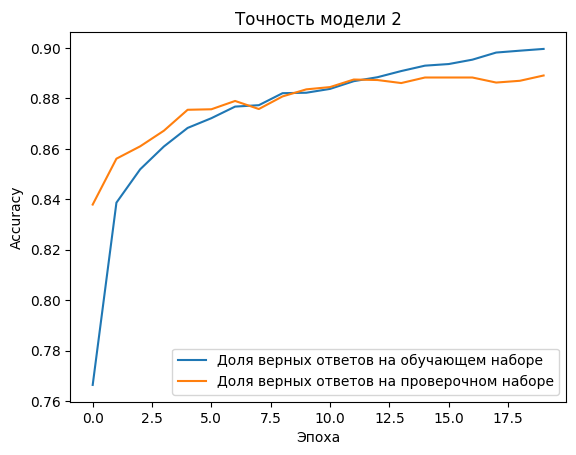

In [7]:
model2 = Sequential([
    Flatten(input_shape=(28,28)),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

model2.compile(loss='categorical_crossentropy', optimizer=Adam(0.001), metrics=['accuracy'])

history2 = model2.fit(x_train, y_train_cat, epochs=20, batch_size=128,
                      validation_data=(x_val, y_val_cat))

scores2 = model2.evaluate(x_test, y_test_cat, verbose=0)

print("Val:", history2.history['val_accuracy'][-1])
print("Test:", scores2[1])

plt.plot(history2.history['accuracy'], label='Доля верных ответов на обучающем наборе')
plt.plot(history2.history['val_accuracy'], label='Доля верных ответов на проверочном наборе')
plt.title("Точность модели 2")
plt.xlabel("Эпоха")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

## Модель 3 - Полносвязная сеть с Batch Normalization и Dropout

Epoch 1/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.8149 - loss: 0.5158 - val_accuracy: 0.8496 - val_loss: 0.4174
Epoch 2/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8528 - loss: 0.4021 - val_accuracy: 0.8595 - val_loss: 0.3798
Epoch 3/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8606 - loss: 0.3758 - val_accuracy: 0.8621 - val_loss: 0.3827
Epoch 4/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8710 - loss: 0.3524 - val_accuracy: 0.8606 - val_loss: 0.3885
Epoch 5/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8748 - loss: 0.3350 - val_accuracy: 0.8622 - val_loss: 0.3786
Epoch 6/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8759 - loss: 0.3316 - val_accuracy: 0.8686 - val_loss: 0.3544
Epoch 7/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8800 - loss: 0.3237 - val_accuracy: 0.8732 - val_loss: 0.3447
Epoch 8/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8849 - loss: 0.3106 - val_accuracy: 0

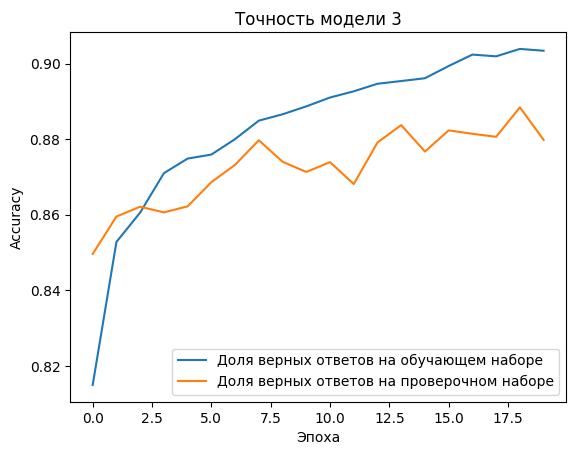

In [8]:
model3 = Sequential([
    Flatten(input_shape=(28,28)),
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

model3.compile(loss='categorical_crossentropy', optimizer=Adam(0.001), metrics=['accuracy'])

history3 = model3.fit(x_train, y_train_cat, epochs=20, batch_size=128,
                      validation_data=(x_val, y_val_cat))

scores3 = model3.evaluate(x_test, y_test_cat, verbose=0)

plt.plot(history3.history['accuracy'], label='Доля верных ответов на обучающем наборе')
plt.plot(history3.history['val_accuracy'], label='Доля верных ответов на проверочном наборе')
plt.title("Точность модели 3")
plt.xlabel("Эпоха")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

## Модель 4 - Углубленная полносвязная нейронная сеть

Epoch 1/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.8390 - loss: 0.4461 - val_accuracy: 0.8318 - val_loss: 0.4587
Epoch 2/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8749 - loss: 0.3403 - val_accuracy: 0.8553 - val_loss: 0.4169
Epoch 3/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8843 - loss: 0.3121 - val_accuracy: 0.8646 - val_loss: 0.3669
Epoch 4/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8924 - loss: 0.2906 - val_accuracy: 0.8655 - val_loss: 0.3720
Epoch 5/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8962 - loss: 0.2789 - val_accuracy: 0.8558 - val_loss: 0.3985
Epoch 6/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9023 - loss: 0.2612 - val_accuracy: 0.8596 - val_loss: 0.3800
Epoch 7/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9081 - loss: 0.2453 - val_accuracy: 0.8816 - val_loss: 0.3346
Epoch 8/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9111 - loss: 0.2371 - val_accuracy: 0

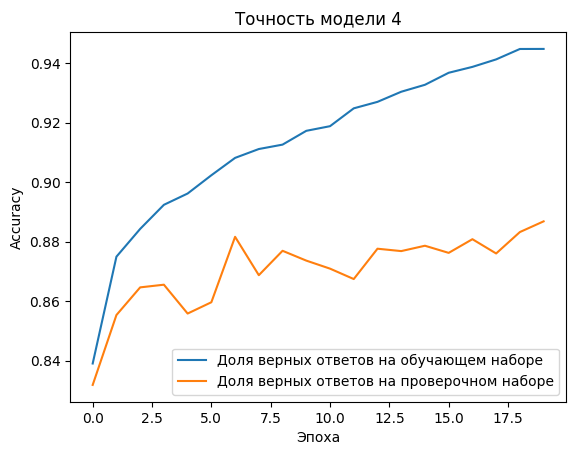

In [9]:
model4 = Sequential([
    Flatten(input_shape=(28,28)),
    Dense(512, activation='relu'),
    BatchNormalization(),
    Dense(256, activation='relu'),
    Dense(10, activation='softmax')
])

model4.compile(loss='categorical_crossentropy', optimizer=Adam(0.001), metrics=['accuracy'])

history4 = model4.fit(x_train, y_train_cat, epochs=20, batch_size=128,
                      validation_data=(x_val, y_val_cat))

scores4 = model4.evaluate(x_test, y_test_cat, verbose=0)

plt.plot(history4.history['accuracy'], label='Доля верных ответов на обучающем наборе')
plt.plot(history4.history['val_accuracy'], label='Доля верных ответов на проверочном наборе')
plt.title("Точность модели 4")
plt.xlabel("Эпоха")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

## Модель 5 - Базовая сверточная нейронная сеть (CNN)

Epoch 1/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.8280 - loss: 0.4900 - val_accuracy: 0.8726 - val_loss: 0.3647
Epoch 2/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8858 - loss: 0.3257 - val_accuracy: 0.8883 - val_loss: 0.3173
Epoch 3/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8995 - loss: 0.2824 - val_accuracy: 0.9025 - val_loss: 0.2748
Epoch 4/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9107 - loss: 0.2481 - val_accuracy: 0.9003 - val_loss: 0.2776
Epoch 5/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9204 - loss: 0.2242 - val_accuracy: 0.9058 - val_loss: 0.2623
Epoch 6/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9284 - loss: 0.2019 - val_accuracy: 0.8984 - val_loss: 0.2817
Epoch 7/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9325 - loss: 0.1870 - val_accuracy: 0.9091 - val_loss: 0.2508
Epoch 8/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9387 - loss: 0.1692 - val_accuracy: 0.

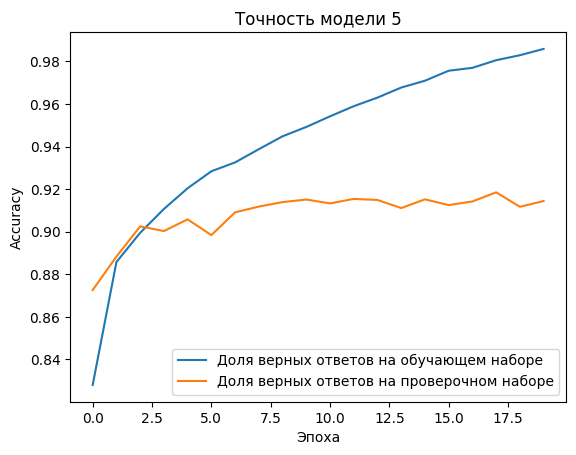

In [10]:
model5 = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    MaxPooling2D(),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

model5.compile(loss='categorical_crossentropy', optimizer=Adam(0.001), metrics=['accuracy'])

history5 = model5.fit(x_train.reshape(-1,28,28,1), y_train_cat,
                      epochs=20, batch_size=128,
                      validation_data=(x_val.reshape(-1,28,28,1), y_val_cat))

scores5 = model5.evaluate(x_test.reshape(-1,28,28,1), y_test_cat, verbose=0)

plt.plot(history5.history['accuracy'], label='Доля верных ответов на обучающем наборе')
plt.plot(history5.history['val_accuracy'], label='Доля верных ответов на проверочном наборе')
plt.title("Точность модели 5")
plt.xlabel("Эпоха")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

## Модель 6 - Сверточная сеть с регуляризацией Dropout

Epoch 1/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.7735 - loss: 0.6221 - val_accuracy: 0.8476 - val_loss: 0.4283
Epoch 2/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8572 - loss: 0.3973 - val_accuracy: 0.8727 - val_loss: 0.3565
Epoch 3/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8754 - loss: 0.3463 - val_accuracy: 0.8839 - val_loss: 0.3306
Epoch 4/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8865 - loss: 0.3152 - val_accuracy: 0.8930 - val_loss: 0.2978
Epoch 5/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8934 - loss: 0.2942 - val_accuracy: 0.8934 - val_loss: 0.2894
Epoch 6/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9004 - loss: 0.2726 - val_accuracy: 0.8930 - val_loss: 0.2956
Epoch 7/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9050 - loss: 0.2566 - val_accuracy: 0.9000 - val_loss: 0.2719
Epoch 8/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9114 - loss: 0.2421 - val_accuracy: 0

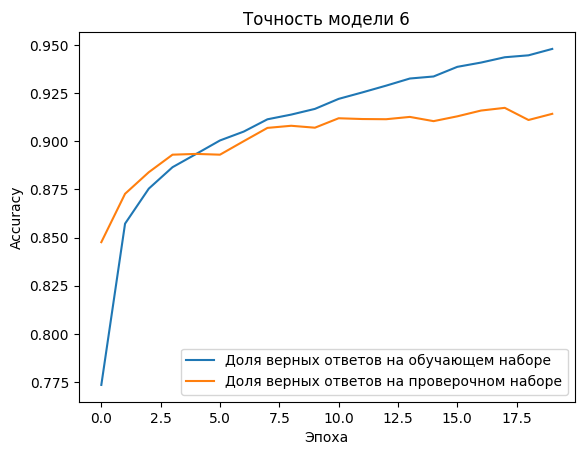

In [11]:
model6 = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    MaxPooling2D(),
    Dropout(0.3),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

model6.compile(loss='categorical_crossentropy', optimizer=Adam(0.001), metrics=['accuracy'])

history6 = model6.fit(x_train.reshape(-1,28,28,1), y_train_cat,
                      epochs=20, batch_size=128,
                      validation_data=(x_val.reshape(-1,28,28,1), y_val_cat))

scores6 = model6.evaluate(x_test.reshape(-1,28,28,1), y_test_cat, verbose=0)

plt.plot(history6.history['accuracy'], label='Доля верных ответов на обучающем наборе')
plt.plot(history6.history['val_accuracy'], label='Доля верных ответов на проверочном наборе')
plt.title("Точность модели 6")
plt.xlabel("Эпоха")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

## Модель 7 - Сверточная сеть с Batch Normalization и Dropout

Epoch 1/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - accuracy: 0.8332 - loss: 0.4667 - val_accuracy: 0.3263 - val_loss: 3.3379
Epoch 2/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8818 - loss: 0.3173 - val_accuracy: 0.8645 - val_loss: 0.3561
Epoch 3/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8977 - loss: 0.2736 - val_accuracy: 0.8814 - val_loss: 0.3107
Epoch 4/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9073 - loss: 0.2469 - val_accuracy: 0.8781 - val_loss: 0.3280
Epoch 5/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9161 - loss: 0.2240 - val_accuracy: 0.8950 - val_loss: 0.2817
Epoch 6/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9222 - loss: 0.2097 - val_accuracy: 0.9057 - val_loss: 0.2655
Epoch 7/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9268 - loss: 0.1941 - val_accuracy: 0.9099 - val_loss: 0.2634
Epoch 8/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9313 - loss: 0.1810 - val_accuracy: 

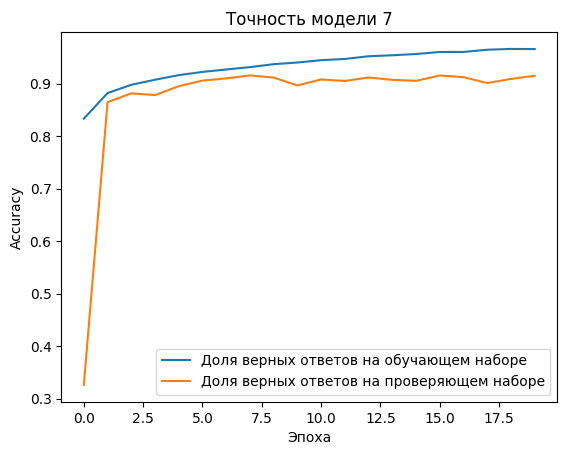

In [12]:
model7 = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    BatchNormalization(),
    MaxPooling2D(),
    Dropout(0.3),
    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

model7.compile(loss='categorical_crossentropy', optimizer=Adam(0.001), metrics=['accuracy'])

history7 = model7.fit(x_train.reshape(-1,28,28,1), y_train_cat,
                      epochs=20, batch_size=128,
                      validation_data=(x_val.reshape(-1,28,28,1), y_val_cat))

scores7 = model7.evaluate(x_test.reshape(-1,28,28,1), y_test_cat, verbose=0)

plt.plot(history7.history['accuracy'], label='Доля верных ответов на обучающем наборе')
plt.plot(history7.history['val_accuracy'], label='Доля верных ответов на проверяющем наборе')
plt.title("Точность модели 7")
plt.xlabel("Эпоха")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

## Модель 8 - Углубленная сверточная сеть с Global Average Pooling

Epoch 1/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - accuracy: 0.4899 - loss: 1.3486 - val_accuracy: 0.6983 - val_loss: 0.8669
Epoch 2/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.6689 - loss: 0.9003 - val_accuracy: 0.7216 - val_loss: 0.7589
Epoch 3/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.7017 - loss: 0.8142 - val_accuracy: 0.7488 - val_loss: 0.6917
Epoch 4/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.7201 - loss: 0.7668 - val_accuracy: 0.7582 - val_loss: 0.6737
Epoch 5/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.7327 - loss: 0.7241 - val_accuracy: 0.7729 - val_loss: 0.6281
Epoch 6/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.7492 - loss: 0.6916 - val_accuracy: 0.7794 - val_loss: 0.6011
Epoch 7/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.7580 - loss: 0.6653 - val_accuracy: 0.7912 - val_loss: 0.5642
Epoch 8/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.7674 - loss: 0.6375 - val_accuracy: 0

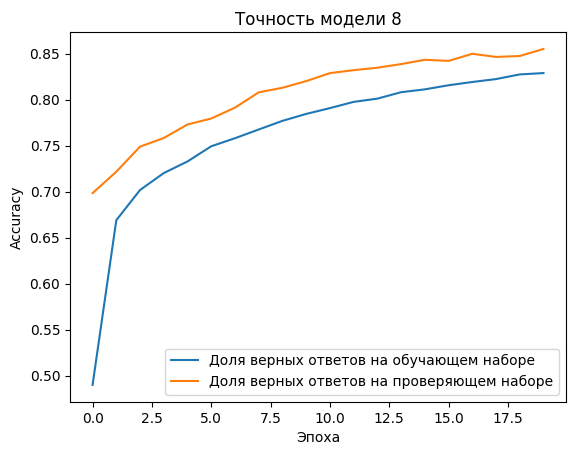

In [13]:
model8 = Sequential([
    Conv2D(64, (3,3), activation='relu', input_shape=(28,28,1)),
    MaxPooling2D(),
    Conv2D(128, (3,3), activation='relu'),
    GlobalAveragePooling2D(),
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

model8.compile(loss='categorical_crossentropy', optimizer=Adam(0.001), metrics=['accuracy'])

history8 = model8.fit(x_train.reshape(-1,28,28,1), y_train_cat,
                      epochs=20, batch_size=128,
                      validation_data=(x_val.reshape(-1,28,28,1), y_val_cat))

scores8 = model8.evaluate(x_test.reshape(-1,28,28,1), y_test_cat, verbose=0)

plt.plot(history8.history['accuracy'], label='Доля верных ответов на обучающем наборе')
plt.plot(history8.history['val_accuracy'], label='Доля верных ответов на проверяющем наборе')
plt.title("Точность модели 8")
plt.xlabel("Эпоха")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

## Модель 9 - Глубокая сверточная сеть с улучшенной архитектурой

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 14s 19ms/step - accuracy: 0.8252 - loss: 0.4771 - val_accuracy: 0.6328 - val_loss: 1.3715
Epoch 2/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8813 - loss: 0.3258 - val_accuracy: 0.8701 - val_loss: 0.3385
Epoch 3/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8948 - loss: 0.2833 - val_accuracy: 0.8953 - val_loss: 0.2856
Epoch 4/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9059 - loss: 0.2575 - val_accuracy: 0.9019 - val_loss: 0.2658
Epoch 5/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9115 - loss: 0.2346 - val_accuracy: 0.8907 - val_loss: 0.3077
Epoch 6/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9178 - loss: 0.2196 - val_accuracy: 0.8825 - val_loss: 0.3268
Epoch 7/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9232 - loss: 0.2030 - val_accuracy: 0.8980 - val_loss: 0.2819
Epoch 8/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9276 - loss: 0.1915 - val_accuracy: 

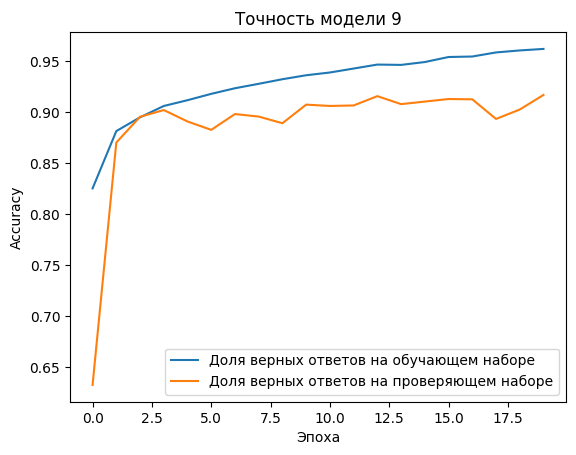

In [3]:
model9 = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    BatchNormalization(),
    MaxPooling2D(),
    Dropout(0.3),
    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(),
    Conv2D(64, (3,3), activation='relu'),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

model9.compile(loss='categorical_crossentropy', optimizer=Adam(0.001), metrics=['accuracy'])

history9 = model9.fit(x_train.reshape(-1,28,28,1), y_train_cat,
                      epochs=20, batch_size=128,
                      validation_data=(x_val.reshape(-1,28,28,1), y_val_cat))

scores9 = model9.evaluate(x_test.reshape(-1,28,28,1), y_test_cat, verbose=0)

plt.plot(history9.history['accuracy'], label='Доля верных ответов на обучающем наборе')
plt.plot(history9.history['val_accuracy'], label='Доля верных ответов на проверяющем наборе')
plt.title("Точность модели 9")
plt.xlabel("Эпоха")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

## Таблица результатов

In [14]:
df = pd.DataFrame({
    "Модель": [f"Model {i}" for i in range(1,10)],
    "Test Accuracy": [
        scores1[1], scores2[1], scores3[1], scores4[1],
        scores5[1], scores6[1], scores7[1], scores8[1], scores9[1]
    ]
})

df

,Модель,Test Accuracy
0,Model 1,0.8826
1,Model 2,0.8821
2,Model 3,0.8744
3,Model 4,0.8858
4,Model 5,0.9121
5,Model 6,0.9136
6,Model 7,0.9117
7,Model 8,0.8542
8,Model 9,0.9157
